Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets       : 11
   Train/Test     : 70% / 30%
   n_estimators   : 100
   max_features   : sqrt
   bootstrap      : False
   class_weight   : balanced
  Extra Trees — n_estimators Sensitivity Analysis

  AAC        → n=50:0.814  n=100:0.819  n=150:0.822  n=200:0.823  n=250:0.827  n=300:0.826
             Best n = 250  (AUC=0.8268)

  DPC        → n=50:0.805  n=100:0.817  n=150:0.820  n=200:0.825  n=250:0.827  n=300:0.826
             Best n = 250  (AUC=0.8274)

  CTDC       → n=50:0.771  n=100:0.784  n=150:0.782  n=200:0.782  n=250:0.783  n=300:0.784
             Best n = 300  (AUC=0.7837)

  CTDT       → n=50:0.785  n=100:0.794  n=150:0.794  n=200:0.793  n=250:0.794  n=300:0.797
             Best n = 300  (AUC=0.7974)

  GAAC       → n=50:0.753  n=100:0.755  n=150:0.755  n=200:0.754  n=250:0.754  n=300:0.754
             Best n = 150  (AUC=0.7552)

  PAAC       → n=50:0.758  n=100:0.774  n=150:0.772  n=200:0.774  n=250

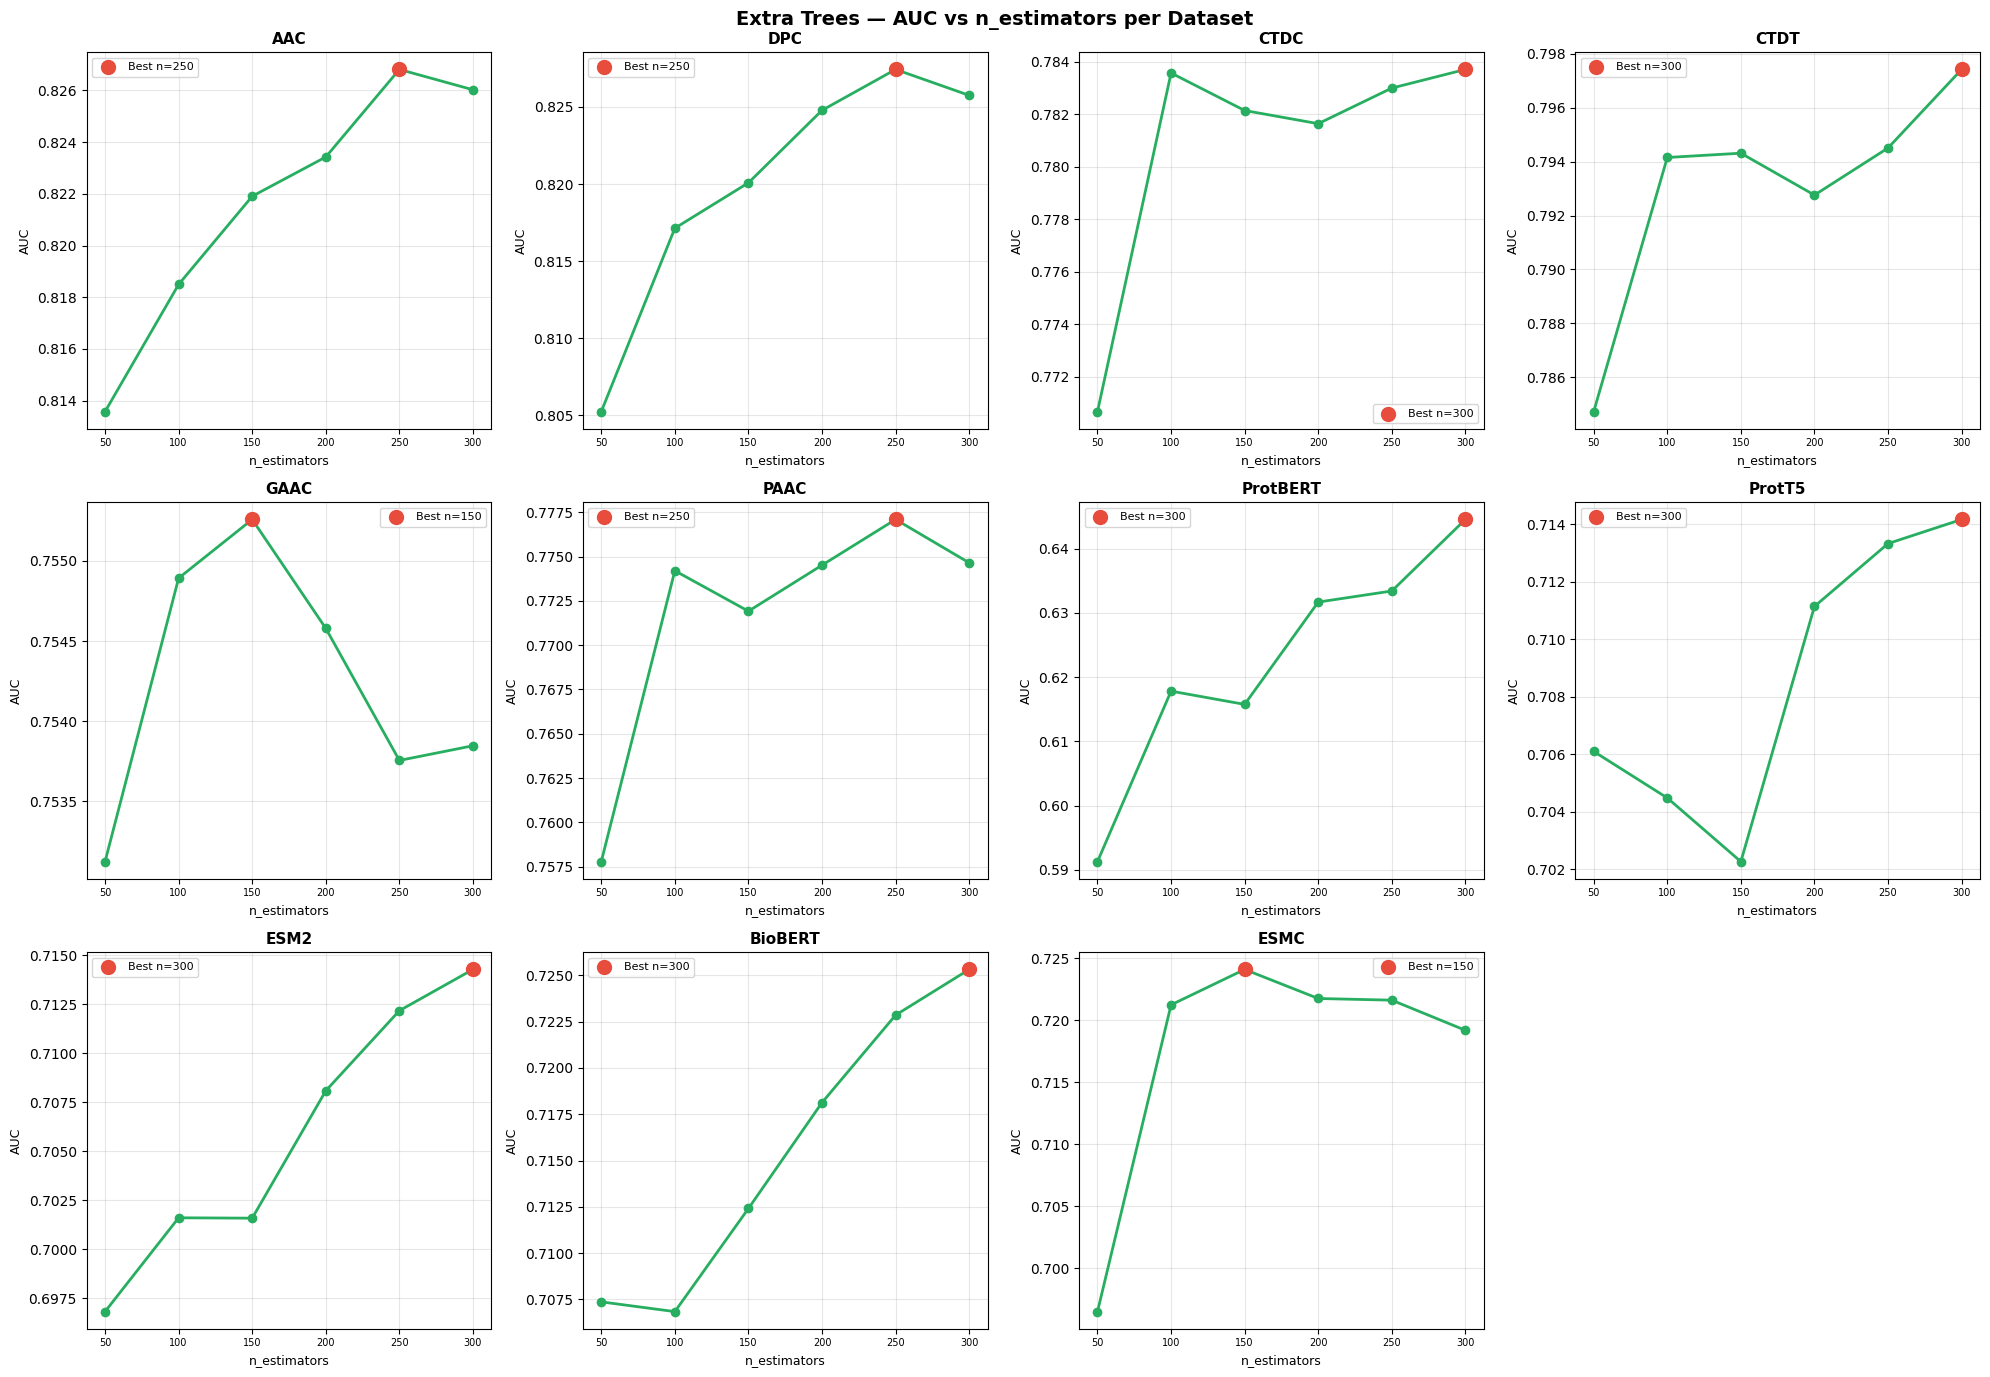

✅ n_estimators sensitivity plot saved
  Extra Trees — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  n_estimators : 250

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7686
  Sensitivity : 0.5703
  Specificity : 0.9010
  F1 Score    : 0.6637
  MCC         : 0.5102
  AUC         : 0.8268
  TP=150  TN=355  FP=39  FN=113
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/extra_trees/AAC_ET_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  n_estimators : 250

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7686
  Sensitivity : 0.5932
  

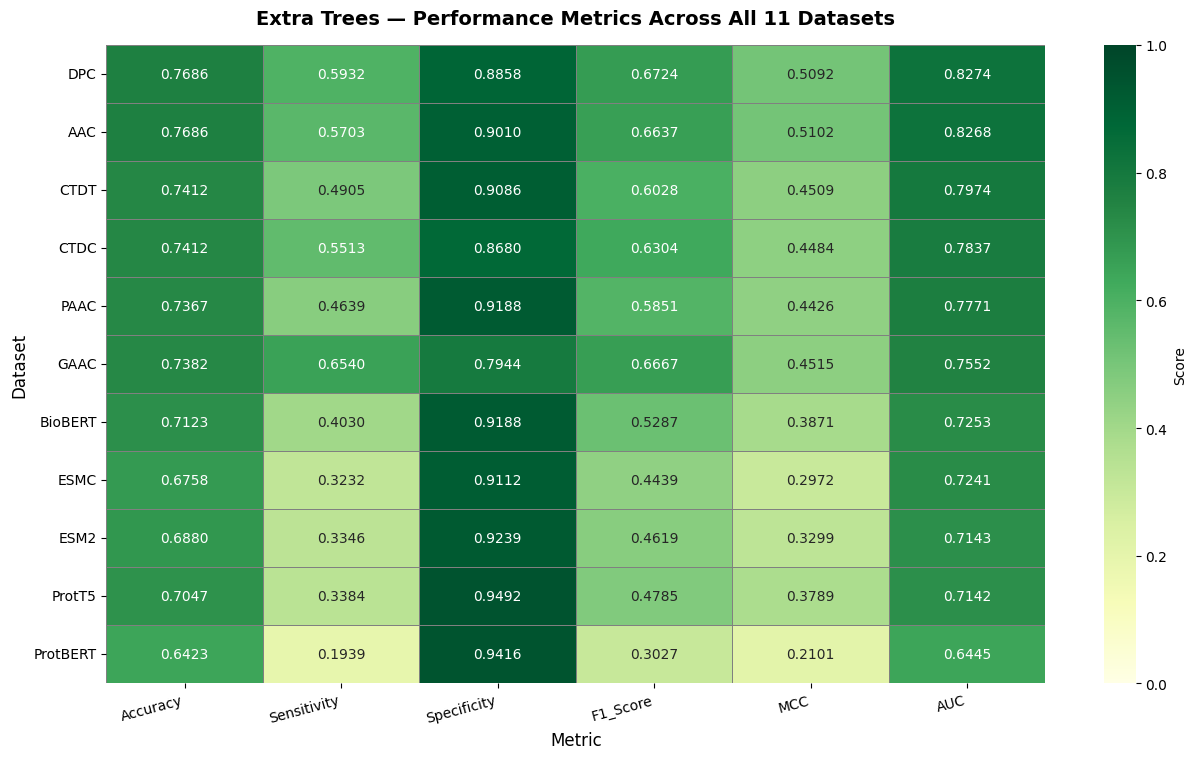

✅ Metrics heatmap saved


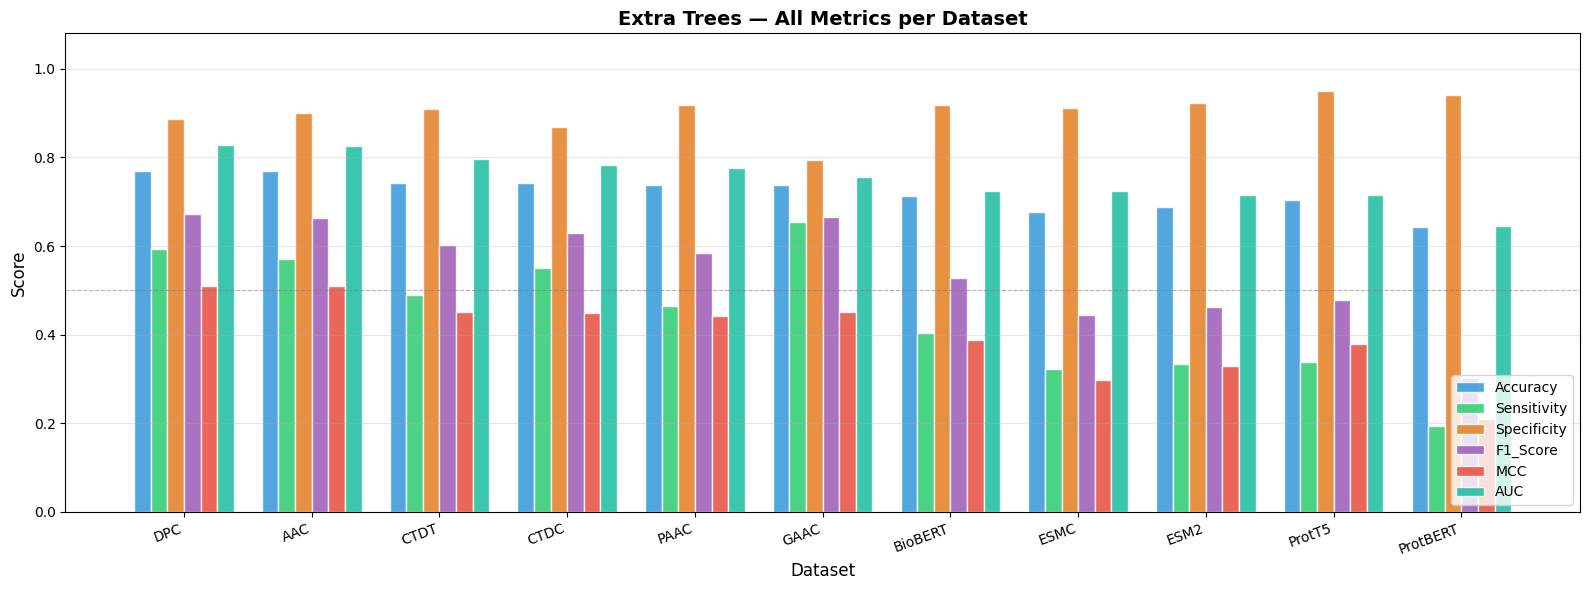

✅ Grouped bar chart saved


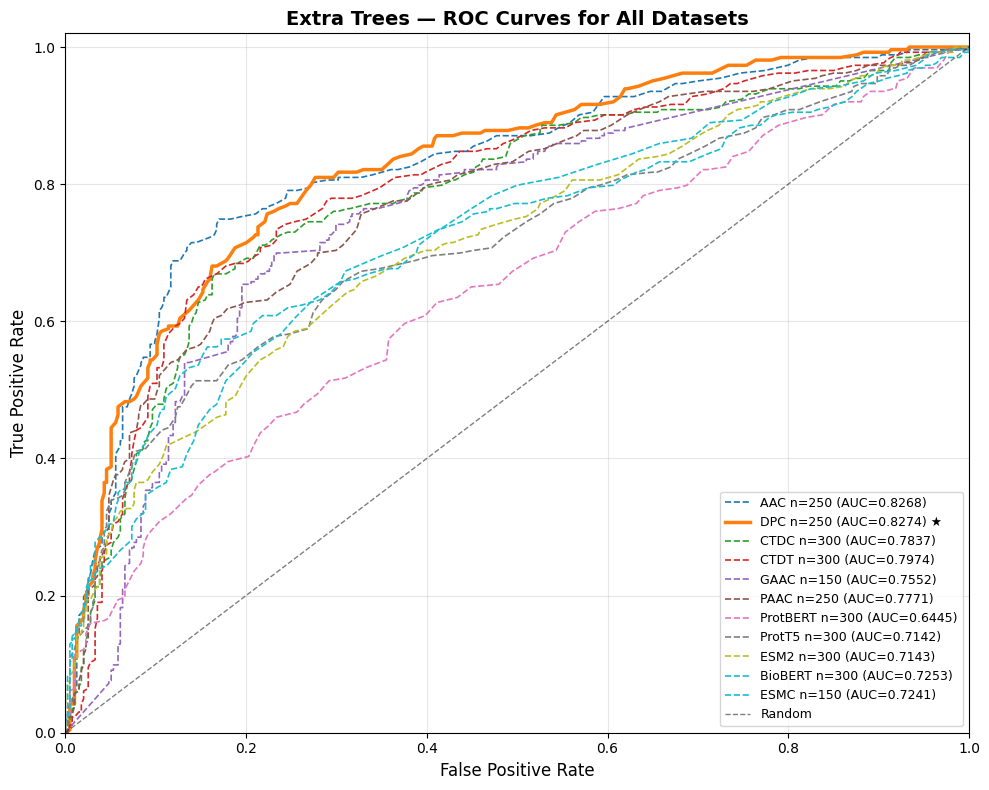

✅ ROC curves saved


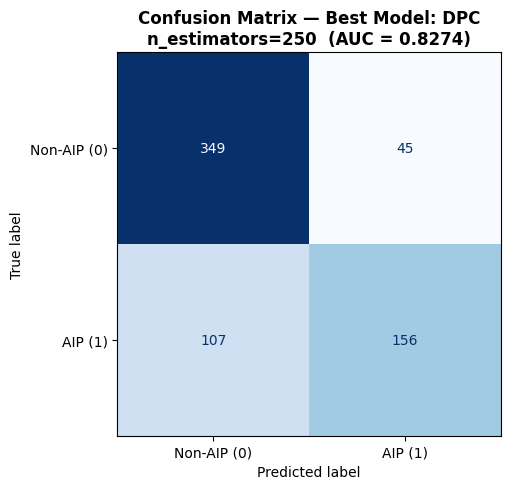

✅ Confusion matrix saved (DPC)


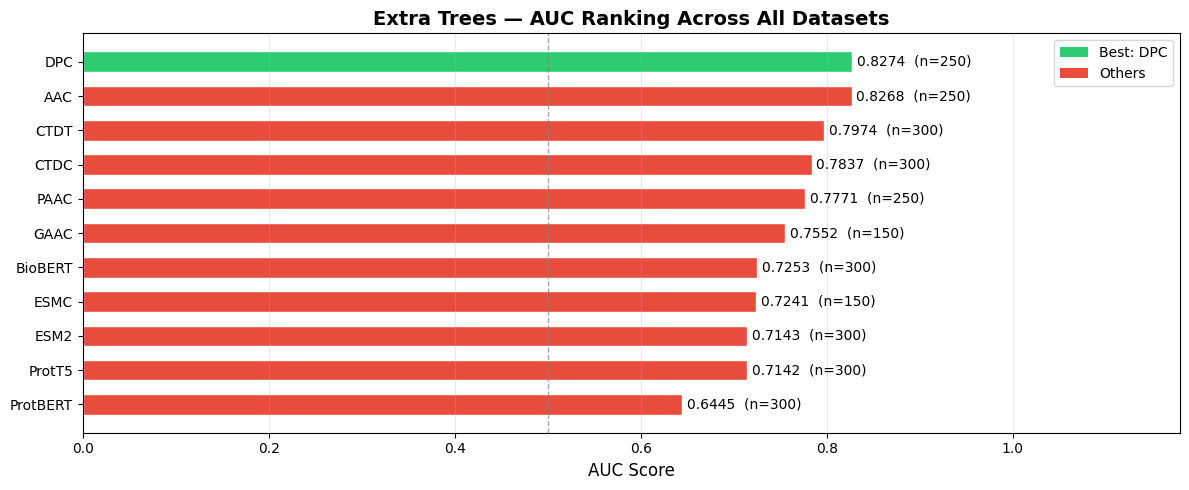

✅ AUC ranking chart saved


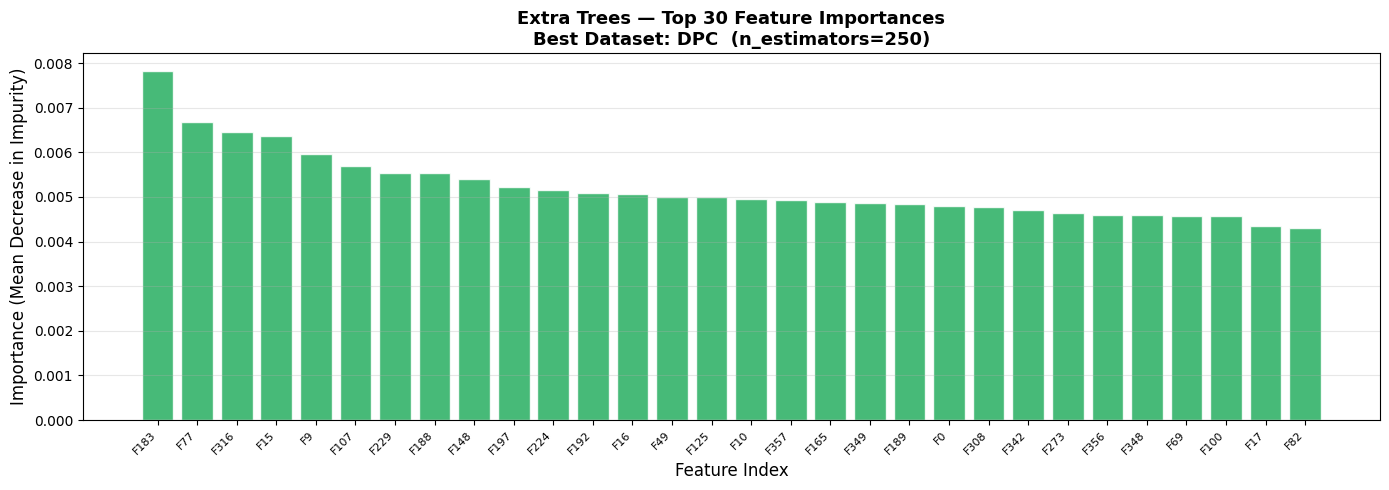

✅ Feature importance plot saved (DPC)


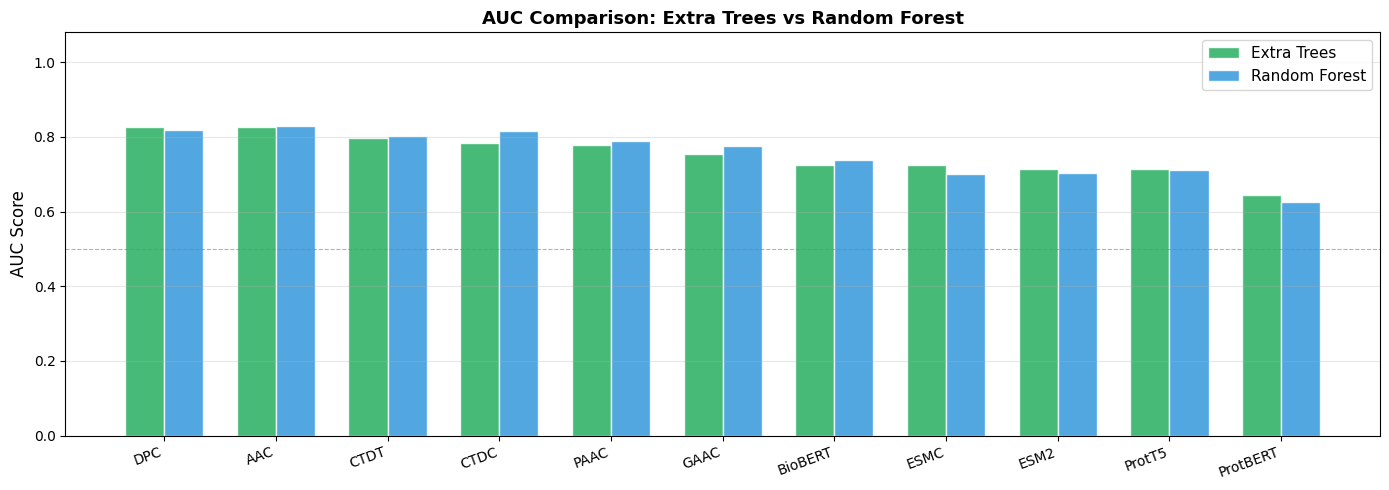

✅ ET vs RF comparison plot saved
  EXTRA TREES — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/extra_trees
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/extra_trees
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/extra_trees

─────────────────────────────────────────────────────────────────
  Dataset          N      Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  DPC            250   0.7686   0.5932   0.8858   0.6724   0.5092   0.8274 ★
  AAC            250   0.7686   0.5703   0.9010   0.6637   0.5102   0.8268
  CTDT           300   0.7412   0.4905   0.9086   0.6028   0.4509   0.7974
  CTDC           300   0.7412   0.5513   0.8680   0.6304   0.4484   0.7837
  PAAC           250   0.7367   0.4639   0.9188   0.5851   0.4426   0.7771
  GAAC           150   0.7382   0.6540   0.7944   0.6667

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/extra_trees"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/extra_trees"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/extra_trees"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── Extra Trees hyperparameters ──────────────────────────────
#
#  Extra Trees (Extremely Randomized Trees) vs Random Forest:
#
#  Random Forest:
#    - Bootstraps training samples per tree (bagging)
#    - Finds BEST split threshold per feature at each node
#
#  Extra Trees:
#    - Uses the FULL training set for each tree (no bootstrap)
#    - Uses RANDOM split thresholds per feature at each node ✅
#    → More randomness = lower variance, faster training
#    → Often matches or beats RF, especially on noisy features
#
#  Key parameters:
#    n_estimators     : number of trees — more = more stable
#    max_depth        : None = fully grown
#                       set 10/20 for high-dim PLM features
#    max_features     : "sqrt" = √n_features per split (default)
#    min_samples_leaf : higher = more regularization
#    class_weight     : "balanced" for 1:1.5 imbalance
#    bootstrap        : False by default in ExtraTrees
#                       (unlike RandomForest which defaults True)
#    n_jobs           : -1 = all CPU cores
#
ET_PARAMS = {
    "n_estimators"     : 100,
    "criterion"        : "gini",
    "max_depth"        : None,
    "max_features"     : "sqrt",
    "min_samples_split": 2,
    "min_samples_leaf" : 1,
    "bootstrap"        : False,    # Extra Trees default — full dataset per tree
    "class_weight"     : "balanced",
    "n_jobs"           : -1,
    "random_state"     : 42,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets       : {len(DATASETS)}")
print(f"   Train/Test     : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   n_estimators   : {ET_PARAMS['n_estimators']}")
print(f"   max_features   : {ET_PARAMS['max_features']}")
print(f"   bootstrap      : {ET_PARAMS['bootstrap']}")
print(f"   class_weight   : {ET_PARAMS['class_weight']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — n_estimators Sensitivity Analysis
#            Tests: 50, 100, 150, 200, 250, 300
#            Finds stable point where AUC plateaus
# ============================================================

print("=" * 65)
print("  Extra Trees — n_estimators Sensitivity Analysis")
print("=" * 65)

N_ESTIMATOR_VALUES = [50, 100, 150, 200, 250, 300]
best_n_per_ds      = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    n_aucs = {}
    for n in N_ESTIMATOR_VALUES:
        et = ExtraTreesClassifier(
            n_estimators  = n,
            criterion     = ET_PARAMS["criterion"],
            max_depth     = ET_PARAMS["max_depth"],
            max_features  = ET_PARAMS["max_features"],
            bootstrap     = ET_PARAMS["bootstrap"],
            class_weight  = ET_PARAMS["class_weight"],
            n_jobs        = ET_PARAMS["n_jobs"],
            random_state  = ET_PARAMS["random_state"],
        )
        et.fit(X_train, y_train)
        y_prob_n = et.predict_proba(X_test)[:, 1]
        n_aucs[n] = round(roc_auc_score(y_test, y_prob_n), 4)

    best_n            = max(n_aucs, key=n_aucs.get)
    best_n_per_ds[ds_name] = best_n

    n_str = "  ".join([f"n={k}:{v:.3f}" for k, v in n_aucs.items()])
    print(f"\n  {ds_name:<10} → {n_str}")
    print(f"             Best n = {best_n}  (AUC={n_aucs[best_n]:.4f})")

print(f"\n✅ n_estimators analysis complete")
print(f"   Best n per dataset: {best_n_per_ds}")


# ============================================================
#   CELL 6 — n_estimators Sensitivity Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    n_aucs = []
    for n in N_ESTIMATOR_VALUES:
        et = ExtraTreesClassifier(
            n_estimators=n,
            criterion=ET_PARAMS["criterion"],
            max_depth=ET_PARAMS["max_depth"],
            max_features=ET_PARAMS["max_features"],
            bootstrap=ET_PARAMS["bootstrap"],
            class_weight=ET_PARAMS["class_weight"],
            n_jobs=-1, random_state=ET_PARAMS["random_state"],
        )
        et.fit(X_train, y_train)
        y_prob_n = et.predict_proba(X_test)[:, 1]
        n_aucs.append(roc_auc_score(y_test, y_prob_n))

    best_n    = best_n_per_ds.get(ds_name, 100)
    best_idx  = N_ESTIMATOR_VALUES.index(best_n)

    ax.plot(N_ESTIMATOR_VALUES, n_aucs, "o-",
            color="#27ae60", linewidth=2, markersize=6)
    ax.scatter([best_n], [n_aucs[best_idx]],
               color="#e74c3c", s=100, zorder=5,
               label=f"Best n={best_n}")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("n_estimators", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_xticks(N_ESTIMATOR_VALUES)
    ax.tick_params(axis="x", labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Extra Trees — AUC vs n_estimators per Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ET_n_estimators_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ n_estimators sensitivity plot saved")


# ============================================================
#   CELL 7 — Main Training Loop (using best n per dataset)
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  Extra Trees — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Use best n_estimators from sensitivity analysis ───────
    n_used = best_n_per_ds.get(ds_name, ET_PARAMS["n_estimators"])
    print(f"  n_estimators : {n_used}")

    # ── Train Extra Trees ────────────────────────────────────
    clf = ExtraTreesClassifier(
        n_estimators      = n_used,
        criterion         = ET_PARAMS["criterion"],
        max_depth         = ET_PARAMS["max_depth"],
        max_features      = ET_PARAMS["max_features"],
        min_samples_split = ET_PARAMS["min_samples_split"],
        min_samples_leaf  = ET_PARAMS["min_samples_leaf"],
        bootstrap         = ET_PARAMS["bootstrap"],
        class_weight      = ET_PARAMS["class_weight"],
        n_jobs            = ET_PARAMS["n_jobs"],
        random_state      = ET_PARAMS["random_state"],
    )
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]  = ds_name
    metrics["Features"] = X.shape[1]
    metrics["N_used"]   = n_used
    metrics["Train_N"]  = len(X_train)
    metrics["Test_N"]   = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_ET_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "clf"   : clf,
        "scaler": scaler,
        "n"     : n_used,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 8 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "N_used", "Accuracy", "Sensitivity",
               "Specificity", "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── Extra Trees Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "ET_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 9 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR, f"ET_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR, f"ET_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset      : {best_name}")
print(f"   n_estimators : {best_n_per_ds.get(best_name)}")
print(f"   AUC          : {best_auc:.4f}")
print(f"   Model        : {best_model_path}")
print(f"   Scaler       : {best_scaler_path}")


# ============================================================
#   CELL 10 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity", "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("Extra Trees — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ET_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 11 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Extra Trees — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ET_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 12 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} n={data['n']} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Extra Trees — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ET_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 13 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"n_estimators={best_n_per_ds.get(best_name)}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"ET_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 14 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, n in zip(bars, sorted_df["AUC"], sorted_df["N_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  (n={n})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("Extra Trees — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ET_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 15 — Visualization 6: Feature Importance (Best Model)
#             Extra Trees gives more uniform importance scores
#             than RF due to higher randomisation — useful for
#             identifying genuinely predictive features
# ============================================================

importances = best_model.feature_importances_
n_top       = min(30, len(importances))
top_idx     = np.argsort(importances)[::-1][:n_top]
top_imp     = importances[top_idx]
top_labels  = [f"F{i}" for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_top), top_imp, color="#27ae60",
       edgecolor="white", alpha=0.85)
ax.set_xticks(range(n_top))
ax.set_xticklabels(top_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Importance (Mean Decrease in Impurity)", fontsize=12)
ax.set_title(f"Extra Trees — Top {n_top} Feature Importances\n"
             f"Best Dataset: {best_name}  "
             f"(n_estimators={best_n_per_ds.get(best_name)})",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"ET_feature_importance_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Feature importance plot saved ({best_name})")


# ============================================================
#   CELL 16 — ET vs RF Comparison (if RF results exist)
#             Loads RF summary CSV and plots side-by-side AUC
# ============================================================

rf_summary_path = (
    "/content/drive/MyDrive/Colab Notebooks/AIP Prediction"
    "/results/random_forest/RF_all_results_summary.csv"
)

if os.path.exists(rf_summary_path):
    df_rf = pd.read_csv(rf_summary_path).set_index("Dataset")

    # Align datasets present in both
    common_ds = [d for d in df_results["Dataset"]
                 if d in df_rf.index]

    et_aucs = df_results.set_index("Dataset").loc[common_ds, "AUC"]
    rf_aucs = df_rf.loc[common_ds, "AUC"]

    x     = np.arange(len(common_ds))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, et_aucs.values, width,
           label="Extra Trees", color="#27ae60",
           alpha=0.85, edgecolor="white")
    ax.bar(x + width/2, rf_aucs.values, width,
           label="Random Forest", color="#3498db",
           alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(common_ds, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("AUC Score", fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.set_title("AUC Comparison: Extra Trees vs Random Forest",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.5, color="grey", linestyle="--",
               linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "ET_vs_RF_AUC_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ ET vs RF comparison plot saved")
else:
    print("ℹ️  RF results not found — skipping ET vs RF comparison")
    print(f"   Run RF_classifier_all_datasets.py first to enable this plot")


# ============================================================
#   CELL 17 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  EXTRA TREES — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'N':>5} {'Acc':>8} {'Sn':>8} {'Sp':>8} "
      f"{'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {int(row['N_used']):>5} "
          f"{row['Accuracy']:>8.4f} "
          f"{row['Sensitivity']:>8.4f} {row['Specificity']:>8.4f} "
          f"{row['F1_Score']:>8.4f} {row['MCC']:>8.4f} "
          f"{row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset  : {best_name}")
print(f"     n_estimators  : {best_n_per_ds.get(best_name)}")
print(f"     Accuracy      : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity   : {best_row['Sensitivity']:.4f}")
print(f"     Specificity   : {best_row['Specificity']:.4f}")
print(f"     F1 Score      : {best_row['F1_Score']:.4f}")
print(f"     MCC           : {best_row['MCC']:.4f}")
print(f"     AUC           : {best_row['AUC']:.4f}")
print(f"\n  Extra Trees vs Random Forest:")
print(f"     ✅ Faster training — no bootstrap, random thresholds")
print(f"     ✅ Lower variance — more randomisation reduces overfit")
print(f"     ✅ Same feature importance API as RF")
print(f"     ✅ Best n_estimators selected per dataset automatically")
print(f"     ✅ ET vs RF comparison plot auto-generated if RF run first")
print("=" * 65)